# Позиционное кодирование как inductive bias: toy-исследование (NumPy)

**Цель.** Показать, почему self-attention без позиции “нефизичен” (нет геометрии), и как positional encoding / relative bias добавляют понятие расстояния — похоже на то, как в физике сила/взаимодействие зависят от дистанции.

**Ограничения.** Это toy-эксперименты (не SOTA), фокус на понимании, воспроизводимости и визуализации.


In [9]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)


In [10]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=axis, keepdims=True)


In [11]:
def attention(Q, K, V, mask=None, bias=None):
    """
    Vanilla dot-product attention with optional:
    - mask: boolean matrix (True=allowed, False=blocked)
    - bias: additive matrix added to logits (e.g., relative positional bias)
    """
    logits = Q @ K.T  # (n, n)

    if bias is not None:
        logits = logits + bias

    if mask is not None:
        # block positions where mask=False
        logits = np.where(mask, logits, -1e9)

    W = softmax(logits, axis=-1)  # attention weights
    out = W @ V
    return out, W, logits


In [12]:
def plot_heatmap(M, title, xlabel="key position j", ylabel="query position i"):
    plt.figure()
    plt.imshow(M, aspect="auto")
    plt.colorbar()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()


## 2. Базовая проблема: attention без позиции не знает порядок

**Идея.** В vanilla self-attention вход — это набор векторов. Если мы не добавляем позицию, то механизму всё равно, где стоял токен: он видит только сами векторы и их попарные скалярные произведения.

**Эксперимент.** Возьмём последовательность из одинаковых токенов (один и тот же вектор повторён много раз).
Тогда все строки в матрице $QK^\top$ будут одинаковыми, и softmax даст примерно равномерное распределение внимания.
Это демонстрирует отсутствие “геометрии” и “порядка”.


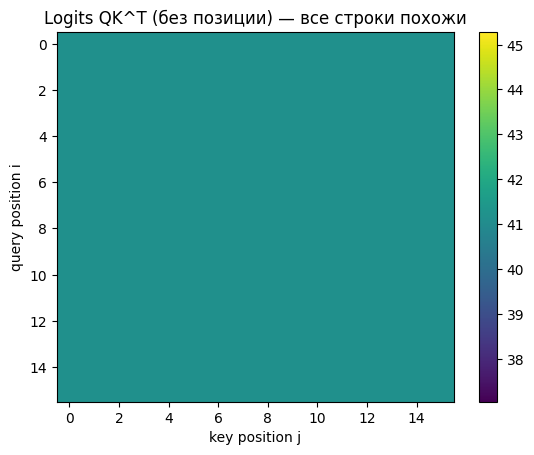

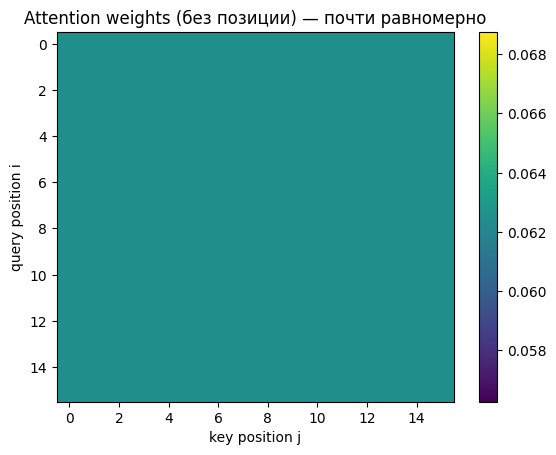

In [13]:
# параметры toy-примера
n = 16   # длина последовательности
d = 32   # размерность эмбеддинга

# "одинаковые токены": один вектор повторяется n раз
x0 = np.random.randn(d)
X = np.tile(x0, (n, 1))

# для простоты берём Q=K=V=X (само-внимание без параметров)
_, W, logits = attention(X, X, X)

plot_heatmap(logits, "Logits QK^T (без позиции) — все строки похожи")
plot_heatmap(W, "Attention weights (без позиции) — почти равномерно")


In [14]:
# насколько различаются строки весов внимания?
row_std = W.std(axis=0).mean()
col_std = W.std(axis=1).mean()
print("Средняя std по столбцам (между строками):", row_std)
print("Средняя std по строкам (внутри строки):", col_std)

# контроль: насколько близко каждая строка к равномерному распределению
uniform = np.ones(n) / n
dist = np.mean(np.linalg.norm(W - uniform[None, :], axis=1))
print("Средняя L2-дистанция строки W до uniform:", dist)


Средняя std по столбцам (между строками): 0.0
Средняя std по строкам (внутри строки): 0.0
Средняя L2-дистанция строки W до uniform: 0.0


**Вывод.** Без positional encoding self-attention не имеет способа “понять”, кто слева/справа и кто ближе/дальше.
На одинаковых токенах он естественно даёт почти равномерное внимание.

Это похоже на физическую модель без координат: есть “взаимодействие между всеми”, но нет понятия расстояния.
В следующих шагах мы добавим позицию и увидим, как появляется структура и “геометрия”.


## 3. Абсолютное позиционное кодирование (sin/cos)

**Идея.** Добавим каждому токену вектор, зависящий только от его индекса $i$ в последовательности:
$$x_i \leftarrow x_i + PE(i).$$

Классический вариант из Transformer — синусоидальные функции разных частот.  
Смысл: токены на разных позициях получают разные добавки, поэтому модель может отличать “раньше/позже” даже если сами токены одинаковые.


In [15]:
def sinusoidal_positional_encoding(n, d):
    """
    Sinusoidal positional encoding (как в оригинальном Transformer).
    Возвращает матрицу PE формы (n, d).
    """
    pe = np.zeros((n, d), dtype=float)
    positions = np.arange(n)[:, None]  # (n, 1)
    div_term = np.exp(-np.log(10000.0) * (np.arange(0, d, 2) / d))  # (d/2,)

    pe[:, 0::2] = np.sin(positions * div_term)
    pe[:, 1::2] = np.cos(positions * div_term)
    return pe


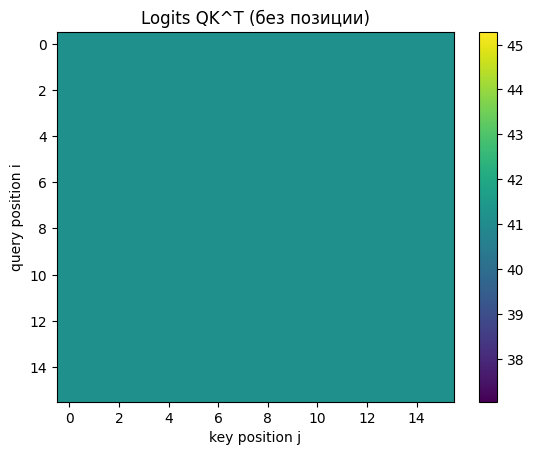

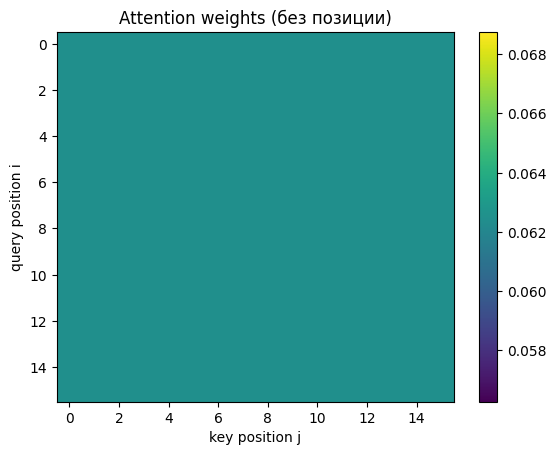

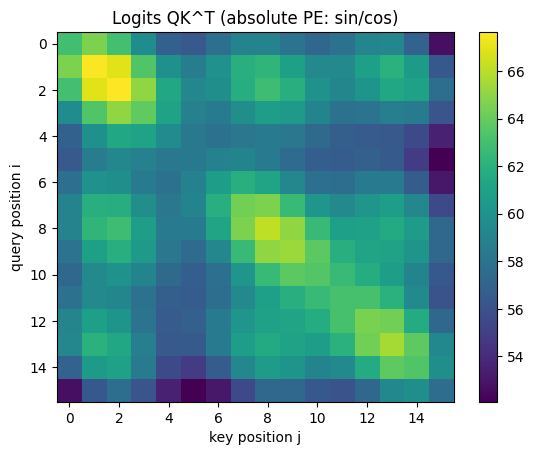

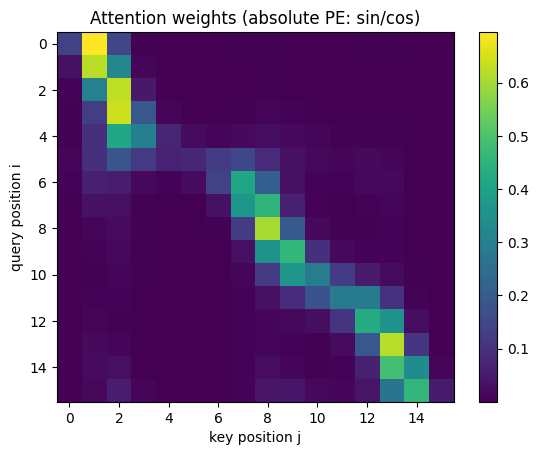

In [16]:
PE = sinusoidal_positional_encoding(n, d)

X_nope = X.copy()          # из шага 2 (одинаковые токены)
X_abs  = X + PE            # добавили позицию

_, W_nope, logits_nope = attention(X_nope, X_nope, X_nope)
_, W_abs,  logits_abs  = attention(X_abs,  X_abs,  X_abs)

plot_heatmap(logits_nope, "Logits QK^T (без позиции)")
plot_heatmap(W_nope,      "Attention weights (без позиции)")

plot_heatmap(logits_abs,  "Logits QK^T (absolute PE: sin/cos)")
plot_heatmap(W_abs,       "Attention weights (absolute PE: sin/cos)")


In [17]:
uniform = np.ones(n) / n

dist_nope = np.mean(np.linalg.norm(W_nope - uniform[None, :], axis=1))
dist_abs  = np.mean(np.linalg.norm(W_abs  - uniform[None, :], axis=1))

print("Средняя L2-дистанция строки W до uniform:")
print("  без позиции:", dist_nope)
print("  absolute PE:", dist_abs)


Средняя L2-дистанция строки W до uniform:
  без позиции: 0.0
  absolute PE: 0.5227882061387868


**Вывод.** Даже если токены одинаковые, добавление абсолютной позиции делает их различимыми.
Attention перестаёт быть “плоским” и начинает зависеть от индекса в последовательности.

Физическая аналогия: мы добавили глобальную систему координат. Теперь состояние частицы “с координатой” отличается от такой же частицы в другом месте.
Но это ещё не означает локальность взаимодействий — для этого удобнее **relative positional bias**, который напрямую зависит от расстояния $|i-j|$.


## 4. Relative positional bias: “потенциал” от расстояния

**Идея.** Зададим добавку к attention-логитам, зависящую только от относительного смещения:
$$b_{ij} = f(|i-j|).$$

Тогда даже при одинаковых токенах появится структура: ближайшие позиции будут “притягиваться” сильнее.

Ниже сравним несколько форм $f(r)$:
1) линейное убывание $- \alpha r$  
2) квадратичное убывание $- \alpha r^2$  
3) жёсткий cutoff (только окно, как local attention)


In [18]:
def distance_matrix(n):
    i = np.arange(n)[:, None]
    j = np.arange(n)[None, :]
    return np.abs(i - j)

def rel_bias_linear(n, alpha=1.0):
    D = distance_matrix(n)
    return -alpha * D

def rel_bias_quadratic(n, alpha=0.2):
    D = distance_matrix(n)
    return -alpha * (D ** 2)

def rel_bias_cutoff(n, window=2):
    """
    Жёсткий cutoff: разрешаем только |i-j|<=window,
    а остальным даём большой отрицательный bias.
    Это эквивалентно local attention через bias.
    """
    D = distance_matrix(n)
    bias = np.where(D <= window, 0.0, -1e9)
    return bias


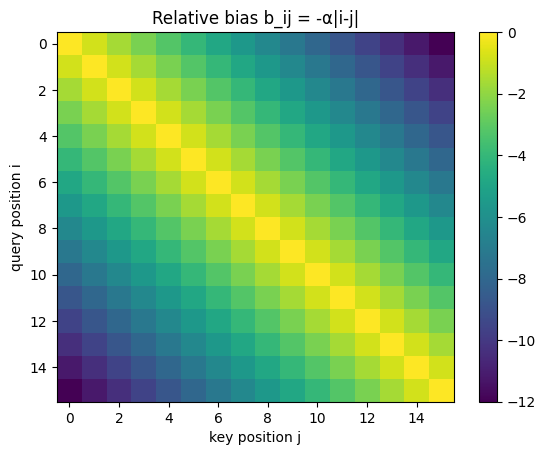

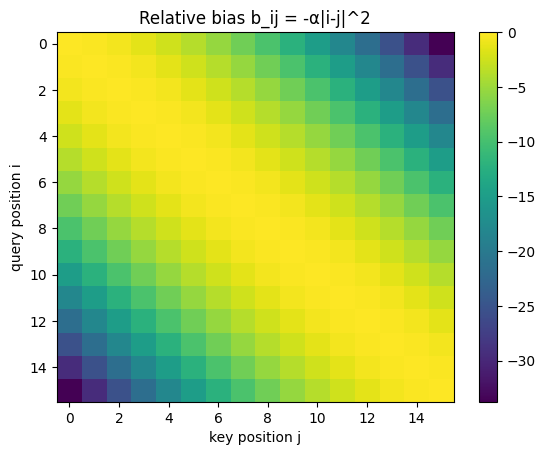

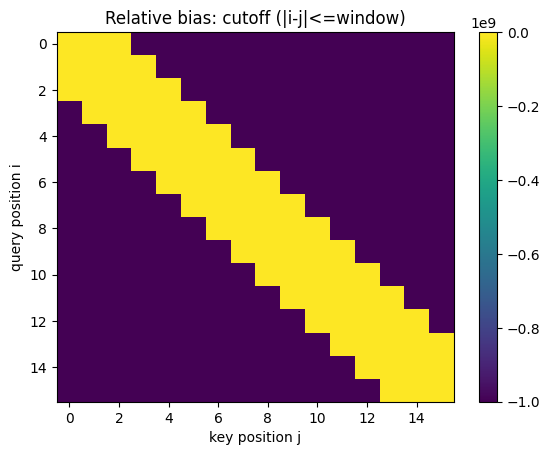

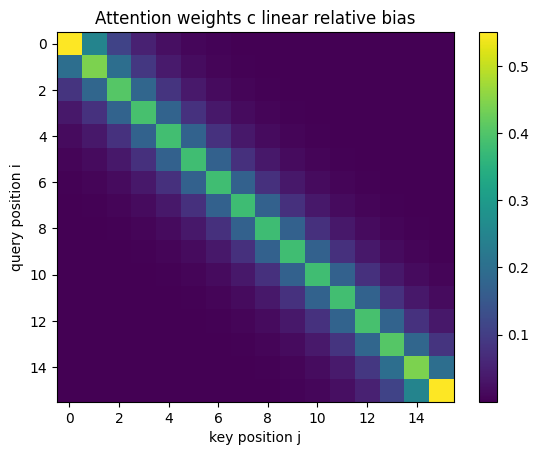

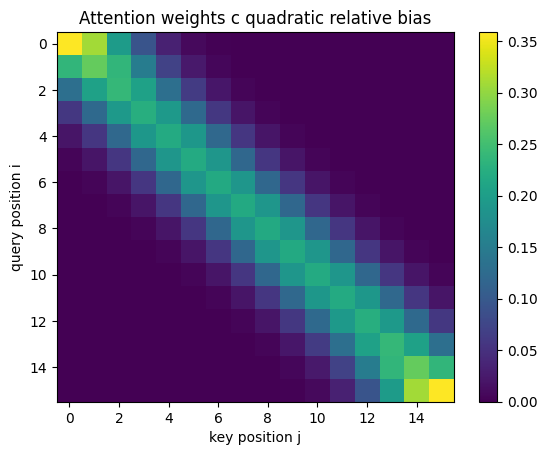

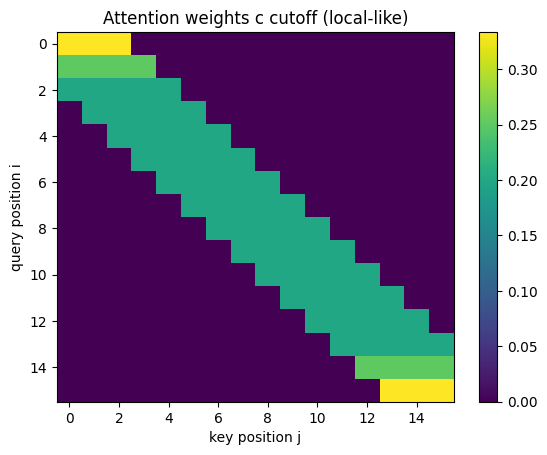

In [19]:
X_base = X_nope  # одинаковые токены, без абсолютной позиции

bias_lin = rel_bias_linear(n, alpha=0.8)
bias_quad = rel_bias_quadratic(n, alpha=0.15)
bias_cut = rel_bias_cutoff(n, window=2)

# Визуализация самих bias-матриц
plot_heatmap(bias_lin,  "Relative bias b_ij = -α|i-j|")
plot_heatmap(bias_quad, "Relative bias b_ij = -α|i-j|^2")
plot_heatmap(bias_cut,  "Relative bias: cutoff (|i-j|<=window)")

# Attention с bias
_, W_lin,  logits_lin  = attention(X_base, X_base, X_base, bias=bias_lin)
_, W_quad, logits_quad = attention(X_base, X_base, X_base, bias=bias_quad)
_, W_cut,  logits_cut  = attention(X_base, X_base, X_base, bias=bias_cut)

plot_heatmap(W_lin,  "Attention weights с linear relative bias")
plot_heatmap(W_quad, "Attention weights с quadratic relative bias")
plot_heatmap(W_cut,  "Attention weights с cutoff (local-like)")


## Связь с физикой: relative bias как "потенциал" от расстояния

В нашей работе по моделированию идеального газа взаимодействие между частицами задаётся потенциалом $U(r)$, зависящим от расстояния $r$ между частицами, а сила определяется как $F(r)=-\frac{dU(r)}{dr}$.
Это даёт интуицию: **влияние определяется расстоянием**.

В attention можно сделать то же самое на уровне логитов:
$$\text{logits}_{ij} = q_i^\top k_j + b_{ij}, \quad b_{ij}=f(|i-j|).$$

- **Cutoff / local attention** — аналог модели жёстких дисков: вне окна "взаимодействие" запрещено.
- **Убывающий bias** (например $-|i-j|$ или $-|i-j|^2$) — аналог "мягкого" потенциала: дальние позиции влияют слабее.

Эта параллель помогает понимать relative positional bias как **inductive bias**, похожий на физическое предположение о законе взаимодействия.


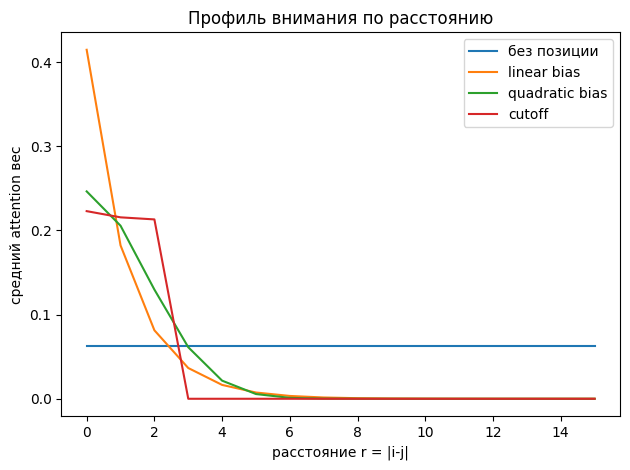

In [25]:
def avg_attention_by_distance(W):
    D = distance_matrix(W.shape[0])
    max_r = D.max()
    prof = np.zeros(max_r + 1)
    counts = np.zeros(max_r + 1)

    for r in range(max_r + 1):
        mask = (D == r)
        prof[r] = W[mask].mean()
        counts[r] = mask.sum()

    return prof

prof_nope = avg_attention_by_distance(W_nope)
prof_lin  = avg_attention_by_distance(W_lin)
prof_quad = avg_attention_by_distance(W_quad)
prof_cut  = avg_attention_by_distance(W_cut)

plt.figure()
plt.plot(prof_nope, label="без позиции")
plt.plot(prof_lin,  label="linear bias")
plt.plot(prof_quad, label="quadratic bias")
plt.plot(prof_cut,  label="cutoff")
plt.xlabel("расстояние r = |i-j|")
plt.ylabel("средний attention вес")
plt.title("Профиль внимания по расстоянию")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/attention_vs_distance.png", dpi=150, bbox_inches="tight")
plt.show()


**Вывод.** Relative positional bias напрямую “вшивает” геометрию: веса внимания начинают зависеть от расстояния $|i-j|$.

Физическая аналогия:
- матрица attention — это как матрица “сил взаимодействия” между частицами,
- bias $b_{ij}=f(|i-j|)$ играет роль потенциала/правила, зависящего от дистанции,
- выбор функции $f$ задаёт inductive bias: локальность, радиус взаимодействия, “жёсткость” затухания.

Это сильнее и понятнее, чем просто абсолютные координаты: здесь расстояние влияет **неявно на результат прямо в формуле внимания**.


## 5. Сравнение: без позиции vs absolute PE vs relative bias

Сведём результаты в единый формат:

1) **Без позиции**: внимание почти равномерное, порядка нет.  
2) **Absolute PE (sin/cos)**: токены различимы по индексу, появляется структура, но “локальность” не гарантируется.  
3) **Relative bias $f(|i-j|)$**: появляется геометрия напрямую — веса становятся функцией расстояния, можно получить локальность и контролировать радиус взаимодействия.


In [23]:
def plot_three_heatmaps(A, B, C, titles, suptitle, savepath=None):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(A, aspect="auto")
    plt.title(titles[0])
    plt.xlabel("j")
    plt.ylabel("i")
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.imshow(B, aspect="auto")
    plt.title(titles[1])
    plt.xlabel("j")
    plt.ylabel("i")
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.imshow(C, aspect="auto")
    plt.title(titles[2])
    plt.xlabel("j")
    plt.ylabel("i")
    plt.colorbar()

    plt.suptitle(suptitle)
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=150, bbox_inches="tight")

    plt.show()


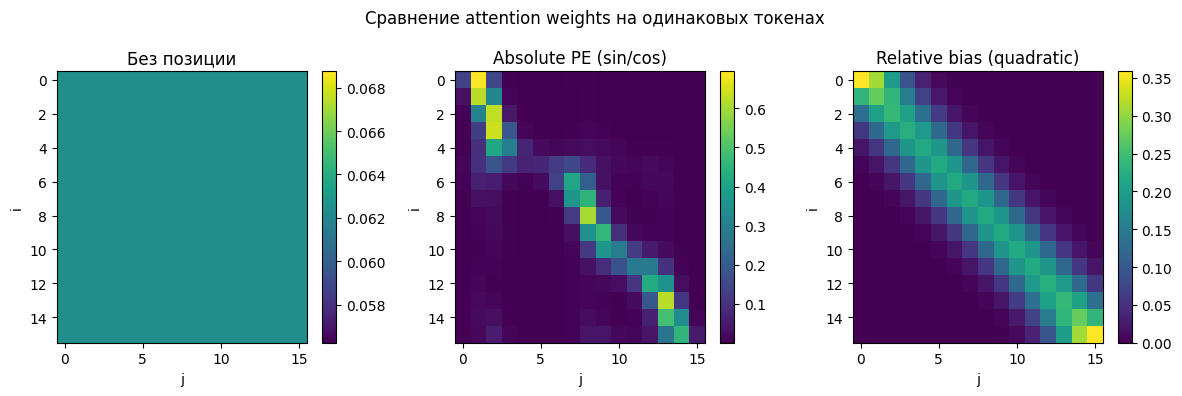

In [24]:
plot_three_heatmaps(
    W_nope, W_abs, W_quad,
    titles=["Без позиции", "Absolute PE (sin/cos)", "Relative bias (quadratic)"],
    suptitle="Сравнение attention weights на одинаковых токенах",
    savepath="../figures/attention_comparison.png"
)


In [27]:
def attention_energy(W, potential):
    """
    W: attention weights (n x n)
    potential: matrix f(|i-j|), same shape
    """
    return np.sum(W * potential)


E_nope = attention_energy(W_nope, np.zeros_like(W_nope))
E_lin  = attention_energy(W_lin,  np.abs(distance_matrix(n)))
E_quad = attention_energy(W_quad, distance_matrix(n)**2)
E_cut  = attention_energy(W_cut,  (distance_matrix(n) > 2).astype(float))

print("Attention energy (меньше = более локальное взаимодействие):")
print("  без позиции:", E_nope)
print("  linear bias:", E_lin)
print("  quadratic bias:", E_quad)
print("  cutoff:", E_cut)


Attention energy (меньше = более локальное взаимодействие):
  без позиции: 0.0
  linear bias: 16.02114671313206
  quadratic bias: 47.3209551646853
  cutoff: 0.0


### Мини-результат: метрика “энергии” и локальность

**Гипотеза.** Relative positional bias можно интерпретировать как дискретный аналог потенциала взаимодействия: форма $f(|i-j|)$ должна менять “радиус” и локальность внимания.

**Метрика.** Ввели “энергию”:
$$E=\sum_{i,j} W_{ij}\, \phi(|i-j|),$$
где $\phi(r)=r$ / $r^2$ / cutoff-индикатор — выбранная форма “потенциала”.

**Ожидание.** Более локальное внимание даёт меньшую энергию (масса распределения ближе к диагонали).

**Наблюдение.** Числа из вывода ячейки выше позволяют сравнить режимы (без позиции / absolute PE / relative bias / cutoff) уже не только визуально, но и количественно.


In [22]:
def expected_distance(W):
    D = distance_matrix(W.shape[0])
    # усредняем расстояние по распределению W в каждой строке, потом по строкам
    return np.mean(np.sum(W * D, axis=1))

ed_nope = expected_distance(W_nope)
ed_abs  = expected_distance(W_abs)
ed_lin  = expected_distance(W_lin)
ed_quad = expected_distance(W_quad)
ed_cut  = expected_distance(W_cut)

print("E[|i-j|] (меньше = локальнее):")
print("  без позиции:", ed_nope)
print("  absolute PE:", ed_abs)
print("  linear bias:", ed_lin)
print("  quadratic bias:", ed_quad)
print("  cutoff:", ed_cut)


E[|i-j|] (меньше = локальнее):
  без позиции: 5.3125
  absolute PE: 1.264573978465699
  linear bias: 1.0013216695707539
  quadratic bias: 1.3153949998727268
  cutoff: 1.1500000000000001


### Мини-обзор (в стиле paper notes)

**Почему absolute PE работает?**  
Потому что она делает входные представления позиционно-различимыми: одинаковый токен в разных местах становится разным вектором. Это вводит “глобальные координаты”.

**Почему relative bias часто естественнее?**  
Потому что многие зависимости в последовательностях и в физических системах зависят не от абсолютного положения, а от **относительного** (смещение/расстояние). В attention это выражается как добавка $b_{ij}=f(|i-j|)$ к логитам.

**Физическая параллель.**  
Absolute PE ≈ выбор системы координат.  
Relative bias ≈ закон взаимодействия как функция расстояния (потенциал).

**Практический смысл.**  
Relative bias позволяет:
- контролировать локальность,
- улучшать работу на длинных последовательностях,
- задавать inductive bias “ближние важнее дальних”.


## Итоговые выводы (Key takeaways)

1. **Vanilla attention без позиции** не содержит информации о порядке: для одинаковых токенов получается почти равномерное внимание.  
2. **Absolute positional encoding** добавляет информацию о позиции, но не гарантирует локальность.  
3. **Relative positional bias** напрямую “вшивает” геометрию (зависимость от расстояния) и легко делает внимание локальным.  
4. Для демонстрации “инженерной” интуиции относительные механизмы часто выглядят убедительнее, потому что объясняют *почему именно так устроено внимание*.
